# Multi-Layer Perceptron (MLP)
auteur : [Maxime Devanne](https://www.maxime-devanne.com)

## Import des librairies

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

2026-02-09 08:27:37.026348: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-09 08:27:37.097003: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-09 08:27:39.143125: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Classification

### Jeu de données Pokemon Stats

#### Téléchargement du dataset

In [2]:
!wget https://maxime-devanne.com/datasets/Pokemon_stats/pokemon-stats-data.csv

--2026-02-09 08:27:39--  https://maxime-devanne.com/datasets/Pokemon_stats/pokemon-stats-data.csv
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving maxime-devanne.com (maxime-devanne.com)... 213.186.33.4, 2001:41d0:1:1b00:213:186:33:4
Connecting to maxime-devanne.com (maxime-devanne.com)|213.186.33.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 22598 (22K) [text/csv]
Saving to: ‘pokemon-stats-data.csv’

pokemon-stats-data. 100%[===================>]  22.07K  --.-KB/s    in 0.002s  

2026-02-09 08:27:39 (10.7 MB/s) - ‘pokemon-stats-data.csv’ saved [22598/22598]



#### Lecture du dataset

In [3]:
df = pd.read_csv("pokemon-stats-data.csv")
df.head()

,name,weight_kg,speed,sp_attack,sp_defense,type
0,Bulbasaur,6.9,45,65,65,grass
1,Ivysaur,13.0,60,80,80,grass
2,Venusaur,100.0,80,122,120,grass
3,Charmander,8.5,65,60,50,fire
4,Charmeleon,19.0,80,80,65,fire


#### Préparation du jeu de données

##### Nettoyage

In [4]:
df = df.dropna()

##### Réduction du jeu données en 3 classes
Nous utiliserons une version réduite du jeu de données avec seulement 3 classes :
- fairy
- ground
- flying

In [5]:
df_types = df[(df["type"] !="test")]
types = df_types["type"].unique()

In [6]:
df = df[(df["type"] == "fairy") | (df["type"] == "ground") | (df["type"] == "flying")]

##### Extraction des données d'entrée qui seront utilisées

Nous utiliserons les 4 attributs numériques :
- weight
- speed
- sp_attack
- sp_defense

In [7]:
X = np.asarray(df[["weight_kg","speed","sp_attack","sp_defense"]], dtype=np.float32)
print(X.shape)

(48, 4)


##### Préparation des données de sortie (étiquettes de classes)
Dans le cas d'une classification multi-classes, il faut passer par une représentation en vecteur one-hot.

In [8]:
y = np.asarray(df["type"])

le = LabelEncoder()
y = le.fit_transform(y)

ohe = OneHotEncoder()
y = ohe.fit_transform(y.reshape(-1,1)).toarray()

print(y.shape)
print(y[0])

(48, 3)
[1. 0. 0.]


##### Séparation en train-test

In [9]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=33/100, random_state=42)

##### Normalisation des données

Pour reproduire un cas réel, la normalisation est "apprise" sur le jeu d'entrainement seulement et ensuite appliquée sur les jeux de données d'apprentissage et de test.

In [10]:
scaler = MinMaxScaler().fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

### Construction d'un MLP

#### Couche d'entrée
Considère des entrées de même taille que celle d'une instance dans `x_train`

In [11]:
input_shape = x_train.shape[1:]
input_layer = tf.keras.layers.Input(input_shape)

#### Couche cachée
Contient 16 neurones avec une activation `sigmoid`

In [12]:
# the hidden layer is connected to the input layer
hidden_layer = tf.keras.layers.Dense(units=16, activation='sigmoid')(input_layer)

2026-02-09 08:27:39.981400: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


#### Couche de sortie
Contient un nombre de neurones égal au nombre de classes avec une activation `softmax`


In [13]:
nb_classes = y_train.shape[1]
output_layer = tf.keras.layers.Dense(units=nb_classes,activation='softmax')(hidden_layer)

#### Création du modèle MLP
On spécifie uniquement la couche d'entrée et la couche de sortie

In [14]:
model_mlp = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

#### Visualisation du modèle construit

In [15]:
# textual information
model_mlp.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# connected graph
tf.keras.utils.plot_model(model_mlp, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


#### Compilation du modèle
Il faut notamment spécifier :
- l'algorithme d'optimisation avec un taux d'apprentissage (learning rate)
- la fonction de coût
- une métrique additionnelle (optionnel)

In [17]:
# Optimizer : Adam
learning_rate = 0.001
optimizer_algo = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# Cost function : Categorical Cross-Entropy
cost_function = tf.keras.losses.categorical_crossentropy

# Model compilation with the 'accuracy' as additional metric
model_mlp.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])

### Entrainement du MLP
Nous allons d'abord définir quelques hyper-paramètres :
- Nombre d'époques
- Taille de batch
- Pourcentage de données utilisées pour la validation
- Model Checkpoint pour garder le meilleur modèle sur la validation au cours de l'entrainement

In [18]:
nb_epochs = 1000
mini_batch_size = 32
percentage_of_train_as_validation = 0.2
model_checkpoint = tf.keras.callbacks.ModelCheckpoint('best-model.h5', monitor='val_loss', save_best_only=True)

#### Lancement de l'entrainement
Il est possible de mettre le paramètre `verbose` à `False` afin de ne pas afficher le déroulé de chaque époque



**Soyez patient :)**

In [19]:
history_mlp = model_mlp.fit(x_train,y_train,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=True,
                    validation_split=percentage_of_train_as_validation,
                    callbacks=[model_checkpoint])

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - accuracy: 0.4400 - loss: 1.0378

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4400 - loss: 1.0378 - val_accuracy: 0.4286 - val_loss: 1.0520
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4400 - loss: 1.0328

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.4400 - loss: 1.0328 - val_accuracy: 0.4286 - val_loss: 1.0491
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4400 - loss: 1.0279

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4400 - loss: 1.0279 - val_accuracy: 0.4286 - val_loss: 1.0463
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4400 - loss: 1.0231

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.4400 - loss: 1.0231 - val_accuracy: 0.4286 - val_loss: 1.0436
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4400 - loss: 1.0184

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8400 - loss: 0.4950 - val_accuracy: 0.7143 - val_loss: 0.7357
Epoch 997/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8400 - loss: 0.4948

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.8400 - loss: 0.4948 - val_accuracy: 0.7143 - val_loss: 0.7357
Epoch 998/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8400 - loss: 0.4946

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8400 - loss: 0.4946 - val_accuracy: 0.7143 - val_loss: 0.7356
Epoch 999/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8400 - loss: 0.4943

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8400 - loss: 0.4943 - val_accuracy: 0.7143 - val_loss: 0.7356
Epoch 1000/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8400 - loss: 0.4941

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8400 - loss: 0.4941 - val_accuracy: 0.7143 - val_loss: 0.7356


Si vous vérifiez, vous avez à présent un fichier 'best-model.h5' qui est sauvegardé. Il contient votre meilleur modèle entraîné

### Tracer la variation du taux d'erreur sur le train et sur le validation set en fonction du nombre d'epoque

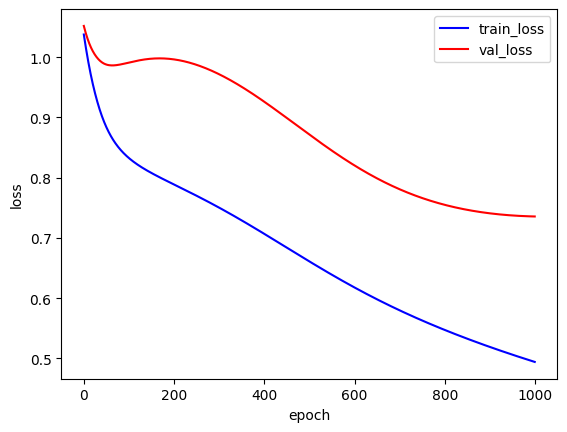

In [20]:
history_dict = history_mlp.history
loss_train_epochs = history_dict['loss']
loss_val_epochs = history_dict['val_loss']

plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss')
plt.plot(loss_val_epochs,color='red',label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss.pdf')
plt.show()
plt.close()

### Choisir le modèle sauveguardé

In [21]:
model = tf.keras.models.load_model('best-model.h5')

### Évaluer l'accuracy de ce meilleur modèle sur le test

In [22]:
loss,acc = model.evaluate(x_test,y_test)

print("L'accuracy sur l'ensemble du test est:",acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.7500 - loss: 0.5447
L'accuracy sur l'ensemble du test est: 0.75


### **Exercices**

#### Essayez d'améliorer le modèle en ajoutant une couche caché de 16 neurones et comparez les résultats:




Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403 (1.57 KB)

 Trainable params: 403 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8800 - loss: 0.4669 - val_accuracy: 0.7143 - val_loss: 0.6933
Epoch 997/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8800 - loss: 0.4666

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8800 - loss: 0.4666 - val_accuracy: 0.7143 - val_loss: 0.6932
Epoch 998/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8800 - loss: 0.4662

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8800 - loss: 0.4662 - val_accuracy: 0.7143 - val_loss: 0.6932
Epoch 999/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8800 - loss: 0.4658

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8800 - loss: 0.4658 - val_accuracy: 0.7143 - val_loss: 0.6931
Epoch 1000/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8800 - loss: 0.4654

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8800 - loss: 0.4654 - val_accuracy: 0.7143 - val_loss: 0.6930


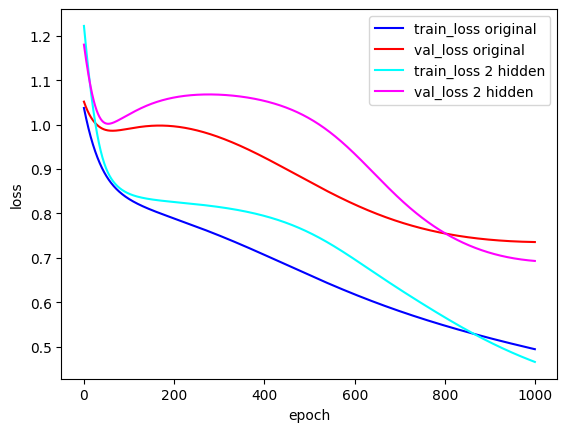

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8125 - loss: 0.5590
L'accuracy sur l'ensemble du test pour le modèle avec 2 couches cachées est: 0.8125
Comparaison: original acc = 0.75 2 hidden acc = 0.8125


In [23]:
# Construction d'un MLP avec deux couches cachées
input_shape = x_train.shape[1:]
input_layer = tf.keras.layers.Input(input_shape)
hidden_layer1 = tf.keras.layers.Dense(units=16, activation='sigmoid')(input_layer)
hidden_layer2 = tf.keras.layers.Dense(units=16, activation='sigmoid')(hidden_layer1)
output_layer = tf.keras.layers.Dense(units=nb_classes,activation='softmax')(hidden_layer2)
model_mlp2 = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
model_mlp2.summary()
tf.keras.utils.plot_model(model_mlp2, show_shapes=True)
# Compilation
optimizer_algo = tf.keras.optimizers.Adam(learning_rate=learning_rate)
cost_function = tf.keras.losses.categorical_crossentropy
model_mlp2.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])
# Entrainement
model_checkpoint2 = tf.keras.callbacks.ModelCheckpoint('best-model2.h5', monitor='val_loss', save_best_only=True)
history_mlp2 = model_mlp2.fit(x_train,y_train,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=True,
                    validation_split=percentage_of_train_as_validation,
                    callbacks=[model_checkpoint2])
# Tracer la variation du taux d'erreur
history_dict2 = history_mlp2.history
loss_train_epochs2 = history_dict2['loss']
loss_val_epochs2 = history_dict2['val_loss']
plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss original')
plt.plot(loss_val_epochs,color='red',label='val_loss original')
plt.plot(loss_train_epochs2,color='cyan',label='train_loss 2 hidden')
plt.plot(loss_val_epochs2,color='magenta',label='val_loss 2 hidden')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss-2hidden.pdf')
plt.show()
plt.close()
# Evaluer
model2 = tf.keras.models.load_model('best-model2.h5')
loss2,acc2 = model2.evaluate(x_test,y_test)
print("L'accuracy sur l'ensemble du test pour le modèle avec 2 couches cachées est:",acc2)
print("Comparaison: original acc =", acc, "2 hidden acc =", acc2)

#### Essayez d'enlever les fonctions d'activation dans les couches cachées (activation='linear') et comparez les résultats

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.8400 - loss: 0.4931 - val_accuracy: 0.7143 - val_loss: 0.6630
Epoch 410/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8400 - loss: 0.4924

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8400 - loss: 0.4924 - val_accuracy: 0.7143 - val_loss: 0.6630
Epoch 411/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8400 - loss: 0.4916

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.8400 - loss: 0.4916 - val_accuracy: 0.7143 - val_loss: 0.6629
Epoch 412/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8400 - loss: 0.4909

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.8400 - loss: 0.4909 - val_accuracy: 0.7143 - val_loss: 0.6629
Epoch 413/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8400 - loss: 0.4902

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.8400 - loss: 0.4902 - val_accuracy: 0.7143 - val_loss: 0.6629
Epoch 414/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8400 - loss: 0.4894 - val_accuracy: 0.7143 - val_loss: 0.6629
Epoch 415/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8400 - loss: 0.4887 - val_accuracy: 0.7143 - val_loss: 0.6629
Epoch 416/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8400 - loss: 0.4880 - val_accuracy: 0.7143 - val_loss: 0.6630
Epoch 417/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8400 - loss: 0.4872 - val_accuracy: 0.7143 - val_loss: 0.6630
Epoch 418/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.8400 - loss: 0.4865 - val_accuracy: 0.7143 - val_loss: 0.6630
Epoch 419/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8400 - loss: 0.4858 - val_accuracy: 0.7143 - val_loss: 0.6630
Epoch 420/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8400 - loss: 0.4851 - val_accuracy: 0

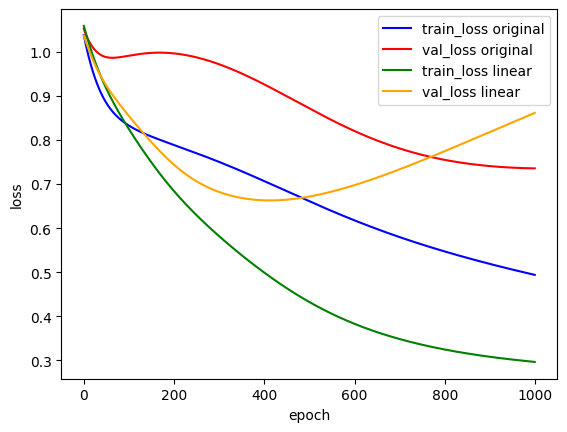

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.6875 - loss: 0.5446
L'accuracy sur l'ensemble du test pour le modèle sans activation est: 0.6875
Comparaison: original acc = 0.75 linear acc = 0.6875


In [24]:
# Construction d'un MLP sans activation dans les couches cachées
input_shape = x_train.shape[1:]
input_layer = tf.keras.layers.Input(input_shape)
hidden_layer = tf.keras.layers.Dense(units=16, activation='linear')(input_layer)
output_layer = tf.keras.layers.Dense(units=nb_classes,activation='softmax')(hidden_layer)
model_mlp3 = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
model_mlp3.summary()
tf.keras.utils.plot_model(model_mlp3, show_shapes=True)
# Compilation
optimizer_algo = tf.keras.optimizers.Adam(learning_rate=learning_rate)
cost_function = tf.keras.losses.categorical_crossentropy
model_mlp3.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])
# Entrainement
model_checkpoint3 = tf.keras.callbacks.ModelCheckpoint('best-model3.h5', monitor='val_loss', save_best_only=True)
history_mlp3 = model_mlp3.fit(x_train,y_train,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=True,
                    validation_split=percentage_of_train_as_validation,
                    callbacks=[model_checkpoint3])
# Tracer la variation du taux d'erreur
history_dict3 = history_mlp3.history
loss_train_epochs3 = history_dict3['loss']
loss_val_epochs3 = history_dict3['val_loss']
plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss original')
plt.plot(loss_val_epochs,color='red',label='val_loss original')
plt.plot(loss_train_epochs3,color='green',label='train_loss linear')
plt.plot(loss_val_epochs3,color='orange',label='val_loss linear')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss-linear.pdf')
plt.show()
plt.close()
# Evaluer
model3 = tf.keras.models.load_model('best-model3.h5')
loss3,acc3 = model3.evaluate(x_test,y_test)
print("L'accuracy sur l'ensemble du test pour le modèle sans activation est:",acc3)
print("Comparaison: original acc =", acc, "linear acc =", acc3)

## Régression

### Jeu de données synthétique

Nous allons créer un jeu de données synthétique représentant la fonction non linéaire à estimer par le MLP.

In [25]:
# Create data with equation y=0.1*x*x*sin(x)
x_data = np.linspace(-10, 10, num=1000)
y_data = 0.1*x_data*x_data*np.sin(x_data) + 0.5*np.random.normal(size=1000)

Affichage du jeu de données

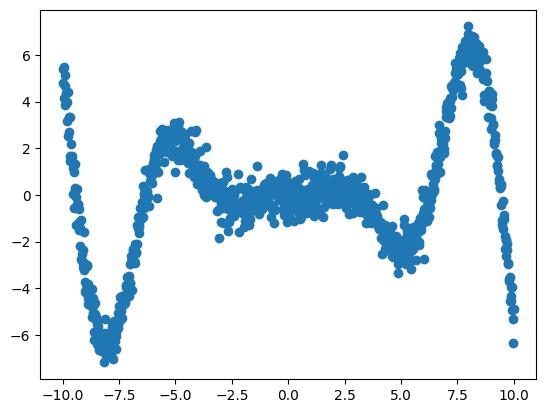

In [26]:
plt.scatter(x_data,y_data)

Ajout d'une dimension aux données pour être compatible avec Keras

In [27]:
x_data = np.expand_dims(x_data,axis=1)
y_data = np.expand_dims(y_data,axis=1)

### Création d'un modèle de regression non linéaire avec Keras

Le modèle contient une couche cachée de 64 neurones.

In [28]:
input_layer = tf.keras.layers.Input(shape=(x_data.shape[1],))
hidden_layer = tf.keras.layers.Dense(units=64,activation='relu')(input_layer)
output_layer = tf.keras.layers.Dense(units=1, activation='linear')(hidden_layer)

multi_layer_model_regression = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
multi_layer_model_regression.summary()
multi_layer_model_regression.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mse')

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

### Entrainement du modèle

In [29]:
nb_epochs = 1000
history = multi_layer_model_regression.fit(x_data,y_data,epochs=nb_epochs,verbose=True)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.1123   
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7256
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5950 
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5756
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4289 
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4030 
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5815 
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3212 
Epoch 9/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1698 
Epoch 10/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2285 
Epoch 11/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1512 
Epoch 12/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1918 
Epoch 13/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1448 
Epoch 14/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0823 
Epoch 15/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s

Courbe d'erreur sur le train en fonction du nombre d'époques

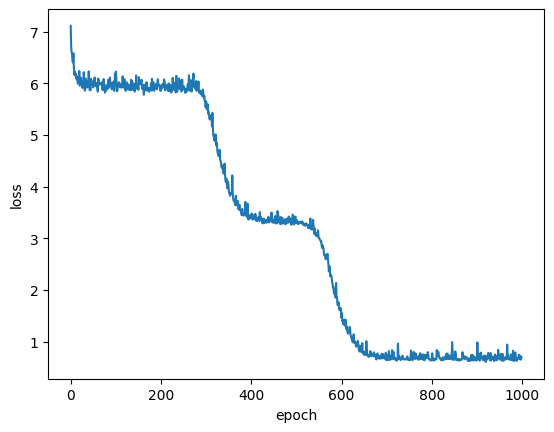

In [30]:
history_dict = history.history
loss_epochs = history_dict['loss']

plt.figure()
plt.plot(loss_epochs)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()
plt.close()

### Evaluation du modèle

In [31]:
loss = multi_layer_model_regression.evaluate(x_data,y_data,verbose=False)

print("Le taux d'erreur sur l'ensemble du test est:",loss)

Le taux d'erreur sur l'ensemble du test est: 0.6334806084632874


Affichage de la courbe de prédiction

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


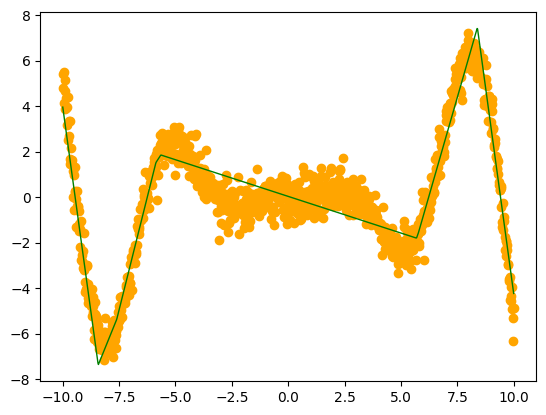

In [32]:
# Compute the output
y_predicted = multi_layer_model_regression.predict(x_data)

# Display the result
plt.scatter(x_data[::1], y_data[::1], color='orange')
plt.plot(x_data, y_predicted, 'g', linewidth=1)

### **Exercice**

#### Ajoutez une deuxième couche cachée de 64 neurones et comparez les prédictions

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,353 (17.00 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.5160  
Epoch 2/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6608
Epoch 3/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4698
Epoch 4/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4278
Epoch 5/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3107
Epoch 6/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1268
Epoch 7/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1556 
Epoch 8/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0545 
Epoch 9/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.9440 
Epoch 10/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.5675 
Epoch 11/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.5885 
Epoch 12/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.2926
Epoch 13/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.0520 
Epoch 14/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.0420
Epoch 15/1000
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/s

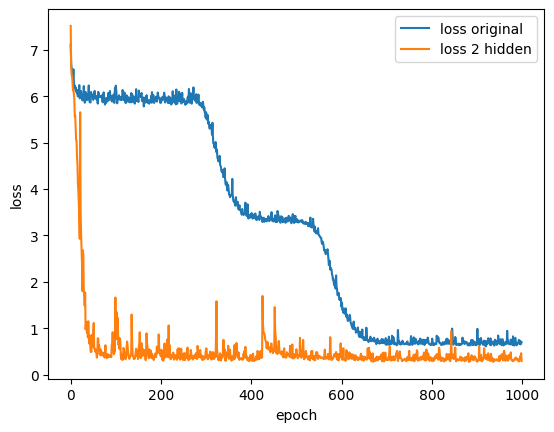

Le taux d'erreur sur l'ensemble du test pour le modèle avec 2 couches cachées est: 0.322870135307312
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


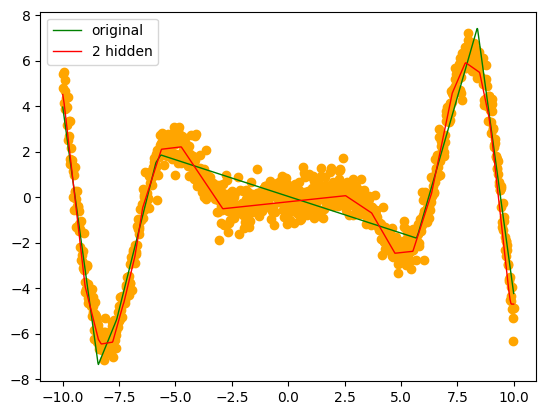

In [33]:
# Création d'un modèle de regression non linéaire avec deux couches cachées
input_layer = tf.keras.layers.Input(shape=(x_data.shape[1],))
hidden_layer1 = tf.keras.layers.Dense(units=64,activation='relu')(input_layer)
hidden_layer2 = tf.keras.layers.Dense(units=64,activation='relu')(hidden_layer1)
output_layer = tf.keras.layers.Dense(units=1, activation='linear')(hidden_layer2)
multi_layer_model_regression2 = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)
multi_layer_model_regression2.summary()
multi_layer_model_regression2.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mse')
# Entrainement du modèle
nb_epochs = 1000
history2 = multi_layer_model_regression2.fit(x_data,y_data,epochs=nb_epochs,verbose=True)
# Courbe d'erreur sur le train en fonction du nombre d'époques
history_dict2 = history2.history
loss_epochs2 = history_dict2['loss']
plt.figure()
plt.plot(loss_epochs, label='loss original')
plt.plot(loss_epochs2, label='loss 2 hidden')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()
plt.close()
# Evaluation du modèle
loss2 = multi_layer_model_regression2.evaluate(x_data,y_data,verbose=False)
print("Le taux d'erreur sur l'ensemble du test pour le modèle avec 2 couches cachées est:",loss2)
# Affichage de la courbe de prédiction
# Compute the output
y_predicted2 = multi_layer_model_regression2.predict(x_data)
# Display the result
plt.scatter(x_data[::1], y_data[::1], color='orange')
plt.plot(x_data, y_predicted, 'g', linewidth=1, label='original')
plt.plot(x_data, y_predicted2, 'r', linewidth=1, label='2 hidden')
plt.legend()
plt.show()